In [2]:
import random
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torchvision.transforms as T
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset

# --- load your dataset ---
dataset = LeRobotDataset(root="/home/rtalwar/robot-imitation-glue/datasets/ground_resized", repo_id="ground_resized")


Resolving data files:   0%|          | 0/173 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Available keys: ['observation.images.wrist_image', 'observation.images.spectogram_image', 'next.reward', 'next.success', 'seed', 'timestamp', 'robot_pose', 'gripper_state', 'joints', 'ft', 'btn_state', 'action', 'frame_index', 'episode_index', 'index', 'task_index', 'observation.state', 'task']


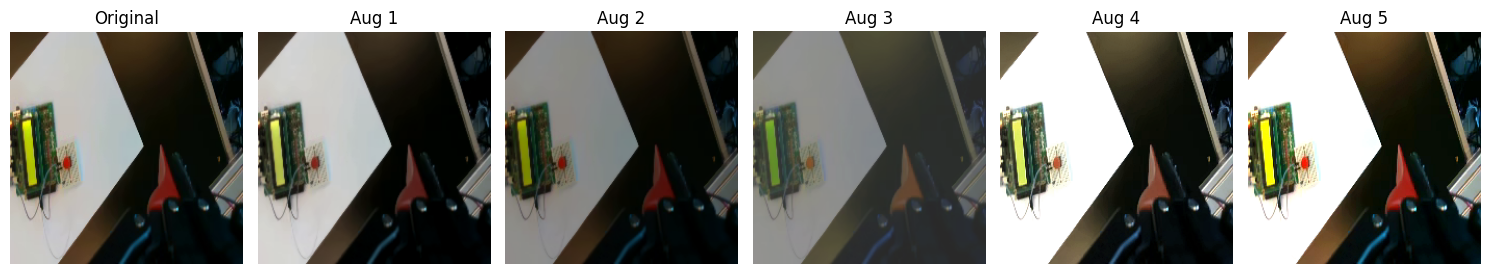

In [18]:

# pick random episode and its first step


episode_idx = random.randint(0, dataset.num_episodes - 1)
step_idx = dataset.episode_data_index["from"][episode_idx].item()

# get observation dict
obs = dataset[step_idx]
print(f"Available keys: {list(obs.keys())}")

# choose which image key you want to visualize
eval_dataset_image_key = "observation.images.wrist_image"  # or "wrist_image" / "rgb" depending on dataset
img_tensor = obs[eval_dataset_image_key]  # shape [C, H, W], float32 [0,1]

# convert tensor -> PIL image
img = T.ToPILImage()(img_tensor)

# --- define your transforms (from config) ---
transform_list = [
    T.ColorJitter(brightness=(0.5, 1.5)),
    T.ColorJitter(contrast=(0.5, 1.5)),
    T.ColorJitter(saturation=(0.5, 1.5)),
    T.ColorJitter(hue=(-0.1, 0.1)),
]

def apply_sharpness(img, factor_range=(0.5, 1.5)):
    factor = random.uniform(*factor_range)
    enhancer = ImageEnhance.Sharpness(img)
    return enhancer.enhance(factor)

# apply up to 3 random transforms
def random_image_transform(img, max_num_transforms=3, random_order=True):
    tfs = transform_list.copy()
    if random_order:
        random.shuffle(tfs)
    tfs = random.sample(tfs, k=random.randint(1, max_num_transforms))
    for tf in tfs:
        img = tf(img)
    img = apply_sharpness(img)
    return img

# --- visualize multiple augmentations for the same image ---
n_augs = 5
augmented_imgs = [random_image_transform(img.copy()) for _ in range(n_augs)]

# --- plot original + augmentations ---
plt.figure(figsize=(15, 3))
plt.subplot(1, n_augs + 1, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

for i, aug in enumerate(augmented_imgs):
    plt.subplot(1, n_augs + 1, i + 2)
    plt.imshow(aug)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()